#Kavish Nag
#24070126085
#AIML B1

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [27]:
digits = load_digits()

X = digits.data
y = digits.target
images = digits.images

print("Dataset shape:", X.shape)

Dataset shape: (1797, 64)


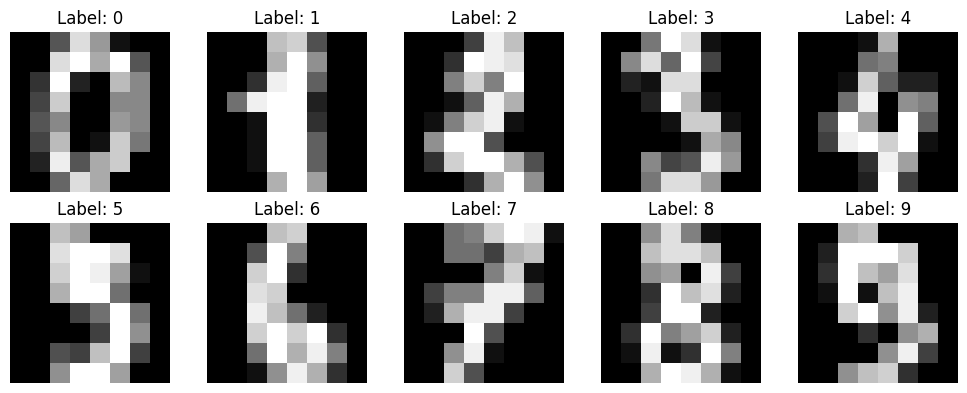

In [28]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

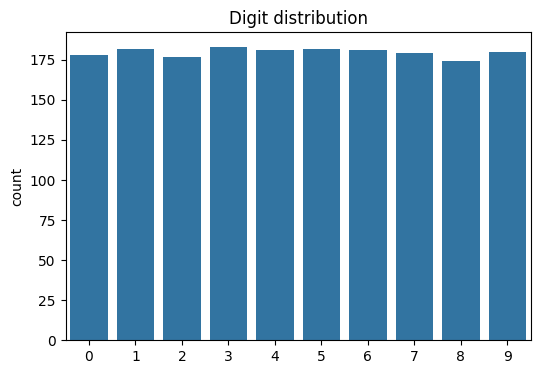

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Digit distribution")
plt.show()

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [31]:
no_svd = LogisticRegression(max_iter=5000)
no_svd.fit(X_train_scaled, y_train)

y_pred_no_svd = no_svd.predict(X_test_scaled)
accuracy_no_svd = accuracy_score(y_test, y_pred_no_svd)

print("Accuracy without SVD:", accuracy_no_svd)

Accuracy without SVD: 0.9722222222222222


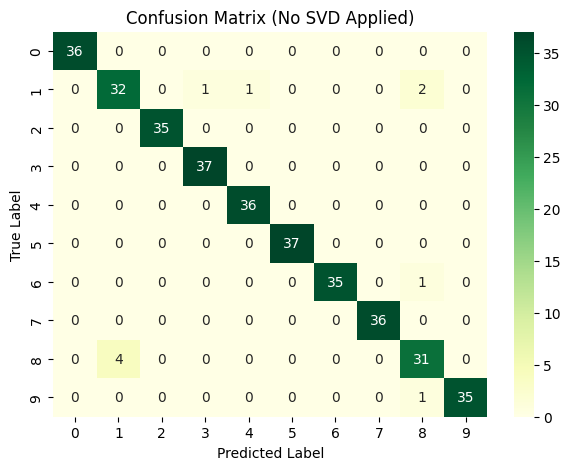

In [32]:
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, y_pred_no_svd),
            annot=True, fmt='d', cmap='YlGn')
plt.title("Confusion Matrix (No SVD Applied)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [33]:
from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=30)
X_train_svd = svd.fit_transform(X_train_scaled)
X_test_svd = svd.transform(X_test_scaled)

In [34]:
model = LogisticRegression(max_iter=5000)
model.fit(X_train_svd, y_train)

LogisticRegression(max_iter=5000)

In [35]:
y_pred_svd = model.predict(X_test_svd)
print("Accuracy with SVD transformation:", accuracy_score(y_test, y_pred_svd))

Accuracy with SVD transformation: 0.9583333333333334


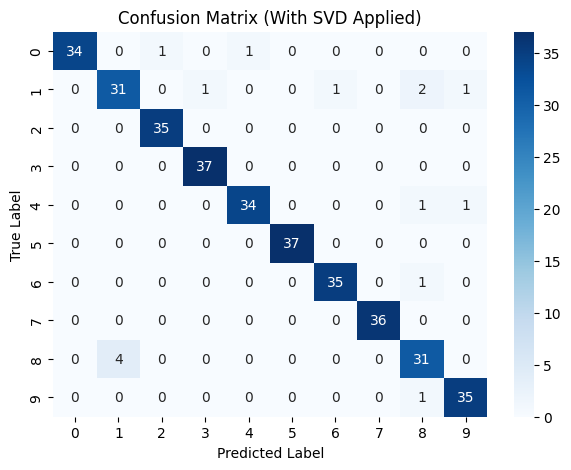

In [36]:
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, y_pred_svd),
            annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (With SVD Applied)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()